# Using supervised sample-level methods

In this tutorial, we will demostrate how to run supervised sample-level methods for single-cell data with `patpy`.

## Import packages

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.13.0'

## Read the data

Here, we use [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed). This dataset contains 783k cells from 140 COVID-19 patients and healthy donors.

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

## Set columns containing sample IDs, cell types and metadata

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

Currently, there is no such columns as "cell_type" in the data. But cell types are stored in the `Annotation_major_subset` column. Let's rename it to `cell_type` for better readability.

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

For this tutorial, we will create a binaru condition column, containing information whether a donor is healthy or comes from COVID-19 group

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int) # 1 for COVID-19, 0 for healthy
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_1391033/647081437.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int) # 1 for COVID-19, 0 for healthy


binary_condition
1    524530
0     87204
Name: count, dtype: int64

## Store metadata and calculate QC metrics

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
cell_qc_metadata = patpy.pp.calculate_cell_qc_metrics(
    adata, sample_key=sample_id_col, cell_qc_vars=["QC_ngenes", "QC_pct_mitochondrial", "QC_scrub_doublet_scores"]
)
n_cells_metadata = patpy.pp.calculate_n_cells_per_sample(adata, sample_id_col)
composition_metadata = patpy.pp.calculate_compositional_metrics(adata, sample_id_col, [cell_type_key], normalize_to=100)
metadata = pd.concat(
    [
        metadata,
        cell_qc_metadata.loc[metadata.index],
        n_cells_metadata.loc[metadata.index],
        composition_metadata.loc[metadata.index],
    ],
    axis=1,
)
metadata

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/pp/basic.py:189: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metadata = adata.obs[[sample_key, *cell_qc_vars]].groupby(by=sample_key)
/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/pp/basic.py:191: FutureWarning: The provided callable <function median at 0x7f1dac67b9c0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  cells_qc_aggregated = metadata.aggregate(agg_function)


,Source,Outcome,Death28,Institute,Pool_ID,binary_condition,median_QC_ngenes,median_QC_pct_mitochondrial,median_QC_scrub_doublet_scores,n_cells,...,cell_type_HSC,cell_type_MAIT,cell_type_Mast,cell_type_NK,cell_type_PB,cell_type_PLT,cell_type_RET,cell_type_cMono,cell_type_iNKT,cell_type_ncMono
scRNASeq_sample_ID,,,,,,,,,,,,,,,,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1,1112.0,0.960763,0.036112,3984,...,0.200803,1.004016,0.000000,20.682731,2.459839,0.075301,0.025100,28.664659,0.050201,1.079317
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1,1068.0,1.286751,0.054808,7384,...,0.135428,0.352113,0.000000,7.624594,2.816901,0.067714,0.000000,23.171723,0.013543,2.559588
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1,1123.0,1.176937,0.066325,9002,...,0.099978,0.288825,0.000000,4.598978,1.832926,0.444346,0.000000,2.777161,0.000000,0.444346
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1,1131.0,1.308555,0.044787,4278,...,0.210379,0.327256,0.000000,8.952782,1.005143,0.116877,0.000000,43.010753,0.023375,3.295933
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1,950.0,1.979107,0.053691,7600,...,0.973684,0.039474,0.026316,5.263158,1.131579,0.236842,0.000000,39.960526,0.013158,2.486842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1,1251.0,2.055921,0.041096,5779,...,0.069216,0.017304,0.017304,8.928880,0.242256,0.155736,0.000000,32.168195,0.017304,7.527254
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1,1251.0,1.500790,0.037953,5195,...,0.134745,0.538980,0.000000,12.281039,0.519731,0.076997,0.000000,19.037536,0.038499,1.828681
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1,1263.0,2.256898,0.049718,3924,...,0.050968,0.050968,0.025484,3.211009,0.433231,0.127421,0.025484,38.863405,0.025484,4.306830


# Quality control

To reduce noise in the representations, we need to remove samples with too few cells:

In [10]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Run MixMIL

[MixMIL](https://arxiv.org/abs/2311.02455) is a method, combining mixed models and multiple instance learning. It learns importance of each cell for a supervised task, aggregates cells with these learned weights, and predicts a label of interest. MixedMIL is a light-weight model and is a great baseline for supervised sample-level tasks. Here, we will show how to use it via `patpy` to distinguish healthy people from COVID-19 patients

Initialize MixMIL. Select the layer you would like to use and a list of tasks. Supported tasks are:
- `"classification"`
- `"regression"`

In [11]:
mixmil = patpy.tl.supervised.MixMIL(
    sample_key=sample_id_col,
    label_keys=["binary_condition"], 
    tasks=["classification"], 
    layer="X_pca",
    n_epochs=100
)

Train the MixMIL model:

In [12]:
mixmil.prepare_anndata(adata)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
Epoch: 100%|██████████| 100/100 [02:04<00:00,  1.25s/it]


We can now display the training history:

Text(0, 0.5, 'Loss')

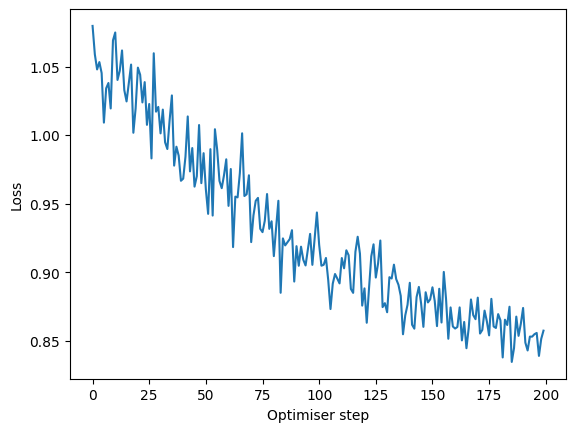

In [13]:
losses = [step["loss"] for step in mixmil.training_history]
plt.plot(losses, label="MixMIL loss")
plt.xlabel("Optimiser step")
plt.ylabel("Loss")

The loss is going down, which is a desired behavior. Note that the number of steps here is bigger than the number of epochs we set. This is because training history contains information for every minibatch of the data. For this dataset and batch size, every epoch consists of 2 steps.

We can now obtain sample embeddings from the model:

In [14]:
mixmil_sample_reps = mixmil.get_sample_representations()
mixmil_sample_reps

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_40,dim_41,dim_42,dim_43,dim_44,dim_45,dim_46,dim_47,dim_48,dim_49
G05061-Ja005E-PBCa,-1.381277,1.341956,-0.457196,-1.456421,-0.330128,-1.155065,-0.913108,0.521566,0.298353,0.858071,...,0.050455,0.191479,-0.086966,-0.146908,0.049881,0.067801,0.042632,-0.081675,-0.021801,-0.128855
G05064-Ja005E-PBCa,-0.840356,-0.758498,-0.385595,-0.936781,-1.270981,-0.677239,-0.238136,-0.872834,0.775794,0.139842,...,-0.000316,0.086494,-0.003116,-0.167811,0.169646,-0.017056,0.009289,-0.028307,-0.022568,0.024029
G05073-Ja005E-PBCa,-0.538473,0.331862,-0.132182,-0.686238,-0.267157,-1.316424,0.237110,0.957211,0.683576,0.903618,...,0.118959,0.088980,-0.039237,0.130772,0.141599,0.017822,0.017913,0.070581,0.083621,-0.170728
G05077-Ja005E-PBCa,-0.527064,1.900464,0.300888,-1.442165,-0.584309,-1.436059,-0.178377,0.058934,0.615683,0.767669,...,0.176571,0.101752,-0.059887,0.181135,0.034280,-0.056092,0.019616,-0.028876,0.061174,-0.013765
G05078-Ja005E-PBCa,-0.832603,-0.414575,-0.206571,-1.346403,-0.957619,-1.585800,-0.586254,-0.052773,0.419745,0.945472,...,0.443253,0.189156,-0.111214,0.076169,0.133255,-0.042016,0.110961,-0.142148,0.008514,-0.070022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00134-Ja003E-PBCa,6.941552,0.031779,-0.624828,-0.280828,0.296835,-0.387412,-0.449077,0.100738,-0.125929,0.074249,...,-0.038420,0.005695,-0.039585,0.186113,-0.074605,0.083164,-0.013090,0.004723,0.080961,0.004850
S00142-Ja005E-PBCa,3.097914,2.850465,1.051137,0.121225,0.224610,-0.820552,-0.150583,0.094237,0.402730,0.786933,...,-0.136479,0.091933,0.033427,0.008240,0.021939,0.000124,0.152159,-0.048620,-0.033645,0.021786
S00148-Ja003E-PBCa,0.750430,2.372979,0.146777,0.036760,-0.081484,-0.807887,0.507421,0.357030,0.096658,-0.360064,...,-0.073529,-0.368383,-0.052634,0.215808,-0.031842,0.076604,0.132863,0.085280,-0.031466,0.029088
U00515-Ua005E-PBUa,-1.533610,0.573506,-0.563373,0.437439,-0.800104,-0.947790,0.095739,-0.886351,0.364036,-0.315162,...,-0.231965,-0.142485,-0.208615,-0.331639,-0.022948,-0.172401,0.108861,0.008939,0.078424,0.112581


And apply our evaluation metrics to them. Here, we test how well binary condition is predicted from the nearest neighbors in the sample representation space:

In [15]:
mixmil_distances = mixmil.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    mixmil_distances, 
    target=metadata.loc[mixmil.samples, "binary_condition"],
    task="classification"
)

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


{'score': np.float64(0.5933275812482024),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

We can then visualise sample representation using dimensionality reduction methods:

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


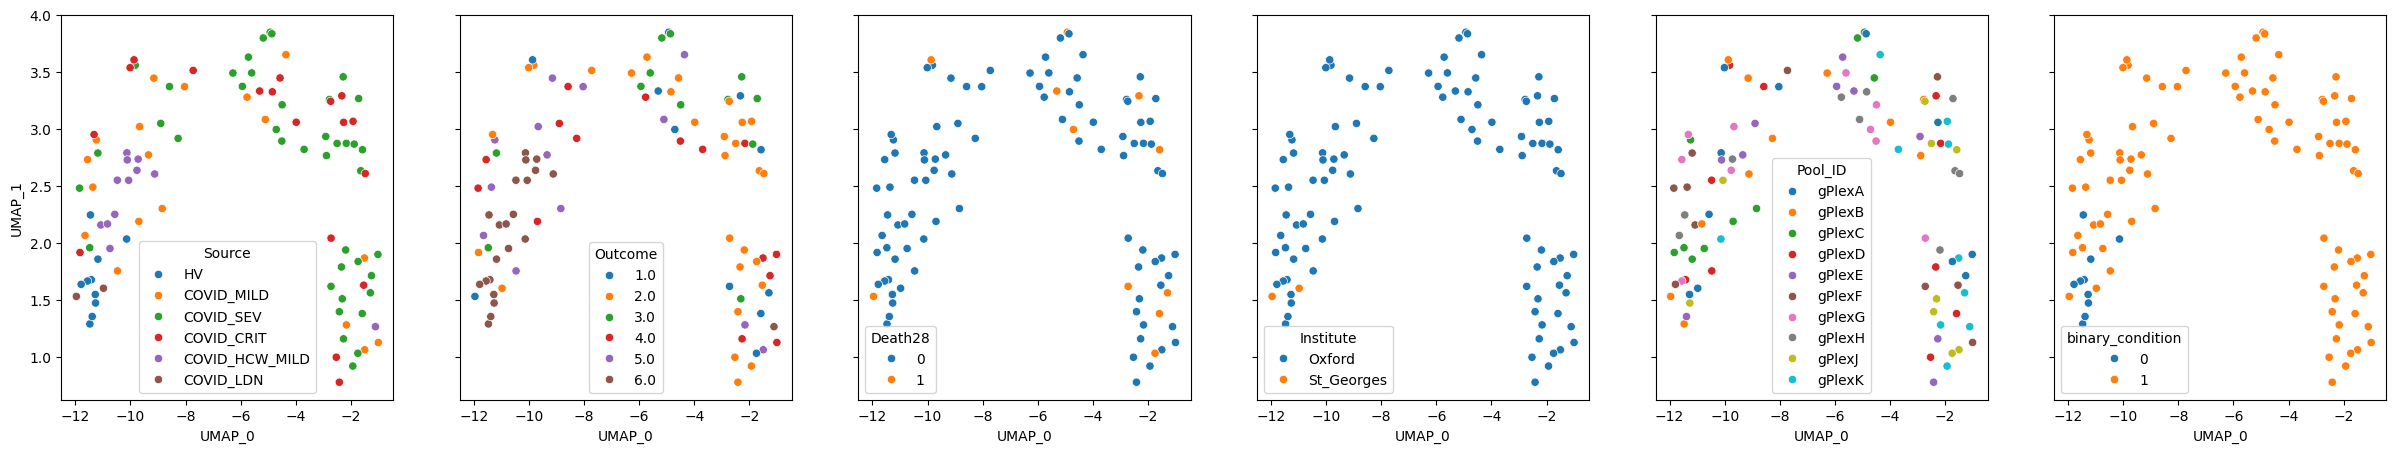

In [16]:
mixmil.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

Additionally, we can predict a label directly with the model:

In [17]:
mixmil_prediction = mixmil.predict("binary_condition")
mixmil_prediction

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


,prob_0,prob_1,binary_condition_pred
G05061-Ja005E-PBCa,0.536446,0.463554,0
G05064-Ja005E-PBCa,0.524378,0.475622,0
G05073-Ja005E-PBCa,0.522635,0.477365,0
G05077-Ja005E-PBCa,0.533199,0.466801,0
G05078-Ja005E-PBCa,0.537712,0.462288,0
...,...,...,...
S00134-Ja003E-PBCa,0.489505,0.510495,1
S00142-Ja005E-PBCa,0.509378,0.490622,0
S00148-Ja003E-PBCa,0.520626,0.479374,0
U00515-Ua005E-PBUa,0.533269,0.466731,0


In [18]:
# Make sure that the order of labels is the same in metadata and prediction
y_true = metadata.loc[mixmil_prediction.index, "binary_condition"]
print(classification_report(y_true, mixmil_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       0.19      1.00      0.32        10
           1       1.00      0.53      0.69        91

    accuracy                           0.57       101
   macro avg       0.59      0.76      0.50       101
weighted avg       0.92      0.57      0.65       101



The prediction is not perfect, but the model is not fully trained as you can see on the loss plot. Let's train it a bit further with a `fine_tune` method:

In [19]:
mixmil.fine_tune("binary_condition", tasks="classification", n_epochs=100, lr=0.001)

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
Epoch: 100%|██████████| 100/100 [00:56<00:00,  1.76it/s]


Text(0, 0.5, 'Loss')

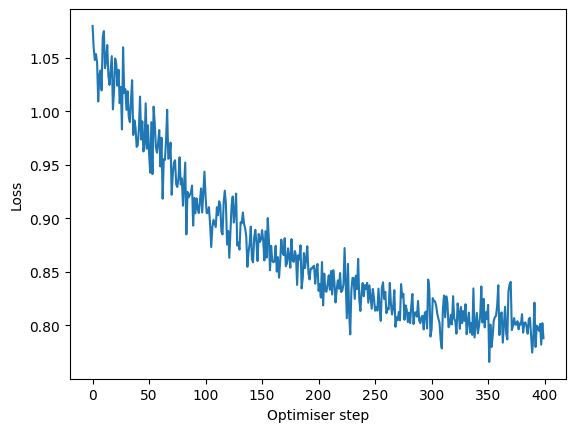

In [20]:
losses = [step["loss"] for step in mixmil.training_history]
plt.plot(losses, label="MixMIL loss")
plt.xlabel("Optimiser step")
plt.ylabel("Loss")

In [21]:
mixmil_prediction = mixmil.predict("binary_condition")

y_true = metadata.loc[mixmil_prediction.index, "binary_condition"]
print(classification_report(y_true, mixmil_prediction["binary_condition_pred"]))

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


              precision    recall  f1-score   support

           0       0.19      1.00      0.32        10
           1       1.00      0.53      0.69        91

    accuracy                           0.57       101
   macro avg       0.59      0.76      0.50       101
weighted avg       0.92      0.57      0.65       101



Interestingly, fine-tuning did not increase the metrics.

Additionally, the model can be fine-tuned for other tasks. For example, let's add classification of all the disease labels:

In [22]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [23]:
mixmil.fine_tune("Source", tasks="classification", n_epochs=100, lr=0.001)

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
Epoch: 100%|██████████| 100/100 [02:51<00:00,  1.72s/it]


Text(0, 0.5, 'Loss')

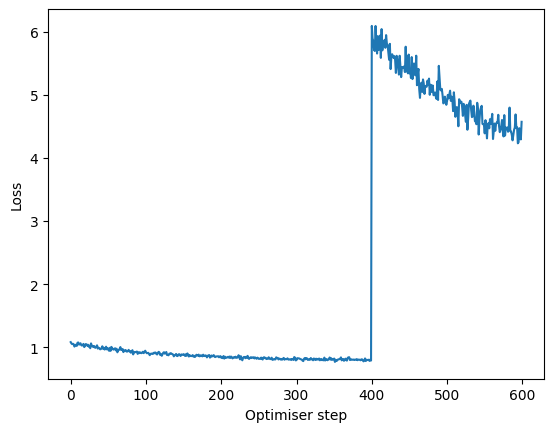

In [24]:
losses = [step["loss"] for step in mixmil.training_history]
plt.plot(losses, label="MixMIL loss")
plt.xlabel("Optimiser step")
plt.ylabel("Loss")

The loss initially jumped, but this is expected because the multi-label classification task is more challenging.

We can now predict the source labels:

In [25]:
mixmil_source_prediction = mixmil.predict("Source")
mixmil_source_prediction

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
G05061-Ja005E-PBCa,0.030640,0.561769,0.074374,0.072961,0.032138,0.228119,COVID_HCW_MILD
G05064-Ja005E-PBCa,0.029576,0.642543,0.096133,0.066386,0.032763,0.132599,COVID_HCW_MILD
G05073-Ja005E-PBCa,0.029037,0.696279,0.060170,0.065821,0.030582,0.118111,COVID_HCW_MILD
G05077-Ja005E-PBCa,0.033331,0.591017,0.072786,0.068909,0.032433,0.201525,COVID_HCW_MILD
G05078-Ja005E-PBCa,0.027393,0.656529,0.072747,0.048350,0.023097,0.171884,COVID_HCW_MILD
...,...,...,...,...,...,...,...
S00134-Ja003E-PBCa,0.231576,0.125973,0.127787,0.131656,0.239131,0.143877,COVID_SEV
S00142-Ja005E-PBCa,0.102261,0.205523,0.118141,0.170917,0.131285,0.271872,HV
S00148-Ja003E-PBCa,0.089273,0.206138,0.137493,0.149648,0.101961,0.315488,HV
U00515-Ua005E-PBUa,0.094870,0.181981,0.220683,0.098946,0.057235,0.346284,HV


In [26]:
source_true = metadata.loc[mixmil_source_prediction.index, "Source"]
print(classification_report(source_true, mixmil_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.55      0.67      0.60        18
COVID_HCW_MILD       0.44      1.00      0.62        12
     COVID_LDN       0.00      0.00      0.00         2
    COVID_MILD       0.00      0.00      0.00        18
     COVID_SEV       0.83      0.46      0.59        41
            HV       0.37      1.00      0.54        10

      accuracy                           0.52       101
     macro avg       0.36      0.52      0.39       101
  weighted avg       0.52      0.52      0.47       101



/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

The model is now trained to jointly predict binary condition and source:

In [27]:
mixmil.label_keys

['binary_condition', 'Source']

We can therefore predict both labels:

In [28]:
mixmil_binary_prediction = mixmil.predict("binary_condition")
binary_condition_true = metadata.loc[mixmil_binary_prediction.index, "binary_condition"]
print(classification_report(y_true, mixmil_binary_prediction["binary_condition_pred"]))

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


              precision    recall  f1-score   support

           0       0.19      1.00      0.32        10
           1       1.00      0.53      0.69        91

    accuracy                           0.57       101
   macro avg       0.59      0.76      0.50       101
weighted avg       0.92      0.57      0.65       101



Let's see how the model represents samples now. We must recompute distances matrix and update the UMAP, otherwise an old embedding will be used:

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


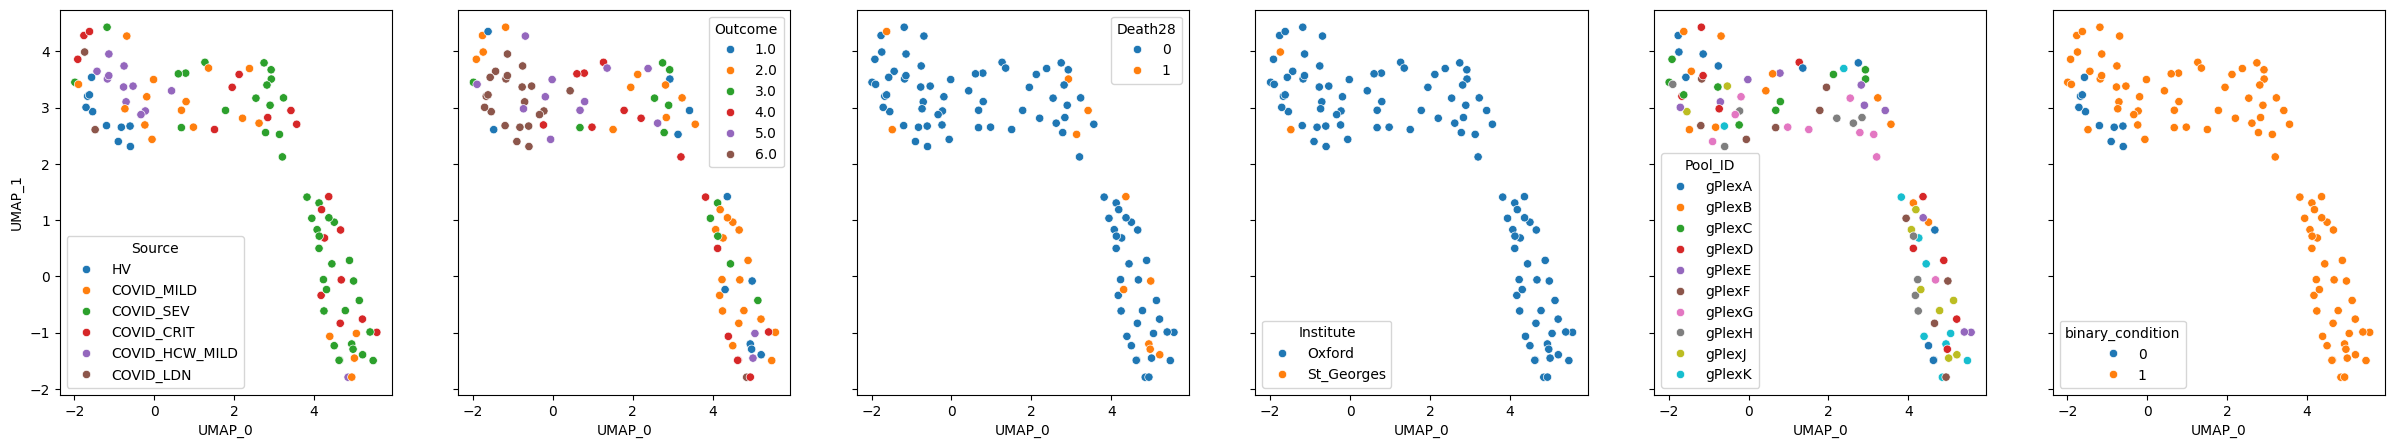

In [29]:
mixmil.calculate_distance_matrix()
mixmil.embed("UMAP")
mixmil.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

# Running PULSAR

Install `helical` to get UCE embeddings. You can use `envs/helical.yaml` conda file in the patpy source directory for an easier installation.

In [ ]:
!pip install patpy[helical]

We need to load the data with raw counts to obtain UCE embeddings

In [ ]:
adata = sc.read_h5ad("/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat.h5ad")
adata

AnnData object with n_obs × n_vars = 836148 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_H

In [29]:
adata.layers["raw"][:30, :30].A

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 8., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0

In [ ]:
adata.X = adata.layers["raw"]

Let's subsample our data object to 1024 cells per sample that PULSAR uses. This will also drastically reduce time to get UCE embeddings

In [31]:
adata = patpy.pp.subsample(adata, obs_category_col=sample_id_col, n_obs=1024, min_samples_per_category=250)
adata

View of AnnData object with n_obs × n_vars = 103460 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'cell_type', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC', 'B

In [32]:
adata = patpy.pp.basic.get_helical_embedding(adata, model="uce", device="cuda")

2026-03-18 18:53:45,955 - INFO:helical.models.uce.model:Model finished initializing.
2026-03-18 18:53:45,957 - INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
2026-03-18 18:53:45,959 - INFO:helical.models.uce.model:Processing data for UCE.
2026-03-18 18:53:52,059 - INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/vladimir.shitov/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
2026-03-18 18:53:52,310 - INFO:helical.models.uce.gene_embeddings:Filtered out 1202 genes to a total of 19605 genes with embeddings.
2026-03-18 18:54:46,924 - INFO:helical.models.uce.uce_utils:Passed the gene expressions (with shape=(103460, 20807) and max gene count data 78359.0) to ./test_counts.npz
2026-03-18 18:54:52,631 - INFO:helical.models.uce.model:Successfully processed the data for UCE.
2026-03-18 18:54:53,273 - INFO:helical.models.uce.model:Started getting embeddings:
100%|██████████| 4311/4311 [58:

In [33]:
adata.obsm["X_uce"].shape

(103460, 1280)

Now goes a bit annoying part... At teh time of writing this tutorial, `helical` requires python version <3.13. And to run PULSAR, we need python >= 3.13. So we need to save the object with UCE embeddings now, change the environment to the one containin python 3.13 and run PULSAR from there. 

In [34]:
adata.write_h5ad("data/combat_subsample_with_uce.h5ad")

Load the data after switching the environment

In [30]:
adata = sc.read_h5ad("data/combat_subsample_with_uce.h5ad")
adata.obsm["X_uce"].shape

(103460, 1280)

You can now run PULSAR via patpy. Before doing that, make sure to install it by running `pip install git+https://github.com/snap-stanford/PULSAR` or simply:

In [ ]:
!pip install patpy[pulsar]

In [31]:
pulsar = patpy.tl.supervised.PULSAR(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"]
)

In [32]:
pulsar.prepare_anndata(adata)

Loading weights: 100%|██████████| 203/203 [00:01<00:00, 157.49it/s]


Resample 0 time


11it [00:02,  4.66it/s]


In [33]:
pulsar_distances = pulsar.calculate_distance_matrix()

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


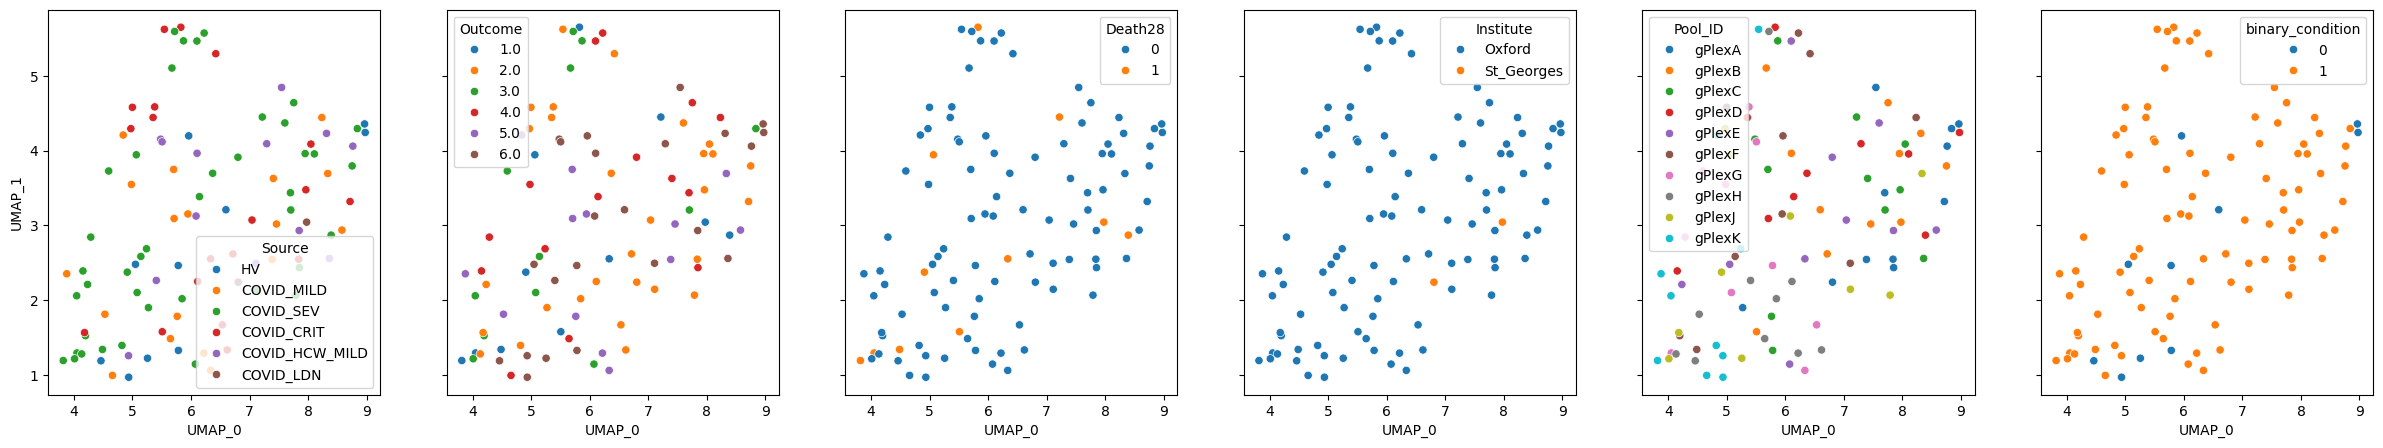

In [34]:
pulsar.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

As we can see, the model doesn't preserve information particularly well, despite being trained on this dataset and having 87 million parameters (on top of underlying 650M for UCE and 15B for ESM2)

Let's give PULSAR another change and load the model fine-tuned for disease prediction

In [35]:
pulsar_aligned = patpy.tl.supervised.PULSAR(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    pretrained_model="KuanP/PULSAR-aligned"
)

In [36]:
pulsar_aligned.prepare_anndata(adata)

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 3414.69it/s]


Resample 0 time


11it [00:01,  6.07it/s]


In [37]:
pulsar_aligned_distances = pulsar_aligned.calculate_distance_matrix()

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


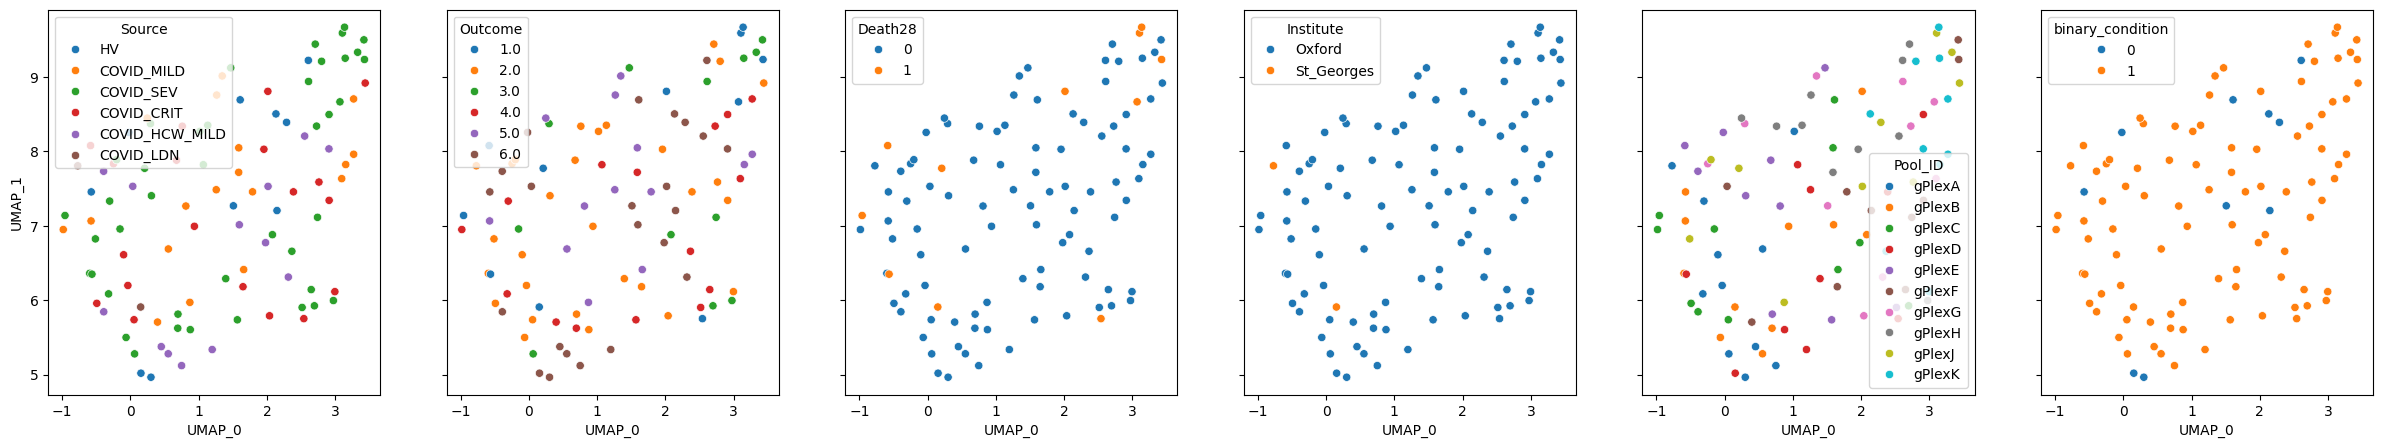

In [38]:
pulsar_aligned.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

We can run apply `fine_tune` to PULSAR as well. In this case, the base model won't be retrained, but instead a small linear classifier will be trained on top of it. We can add as many prediction tasks as we want, they will be trained independently from each other.

In [39]:
pulsar.fine_tune(
    labels=["binary_condition", "Source"], 
    tasks=["classification", "classification"]
)

In [40]:
pulsar_source_prediction = pulsar.predict("Source")
pulsar_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.179383,0.138693,0.154339,0.159889,0.199176,0.168521,COVID_SEV
S00112-Ja003E-PBCa,0.145783,0.164913,0.168011,0.202601,0.146124,0.172568,COVID_MILD
G05153-Ja005E-PBCa,0.145258,0.215347,0.194767,0.139690,0.137902,0.167036,COVID_HCW_MILD
S00005-Ja005E-PBCa,0.162052,0.169440,0.203298,0.152381,0.157898,0.154931,COVID_LDN
S00061-Ja003E-PBCa,0.165861,0.158230,0.187931,0.165523,0.166231,0.156225,COVID_LDN
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.176172,0.156331,0.098420,0.195909,0.191835,0.181333,COVID_MILD
S00072-Ja001E-PBCa,0.158602,0.142858,0.112953,0.209858,0.191977,0.183752,COVID_MILD
S00065-Ja003E-PBCa,0.220320,0.151980,0.084051,0.149645,0.229148,0.164855,COVID_SEV
S00048-Ja003E-PBCa,0.182517,0.150886,0.136704,0.166958,0.192568,0.170367,COVID_SEV


In [42]:
source_true = metadata["Source"]
print(classification_report(source_true, pulsar_source_prediction.loc[metadata.index, "Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.64      0.50      0.56        18
COVID_HCW_MILD       0.50      0.58      0.54        12
     COVID_LDN       0.15      1.00      0.27         2
    COVID_MILD       0.46      0.61      0.52        18
     COVID_SEV       0.79      0.54      0.64        41
            HV       0.75      0.60      0.67        10

      accuracy                           0.56       101
     macro avg       0.55      0.64      0.53       101
  weighted avg       0.65      0.56      0.59       101



In [43]:
pulsar_binary_prediction = mixmil.predict("binary_condition")
binary_condition_true = metadata["binary_condition"]
print(classification_report(y_true, pulsar_binary_prediction.loc[metadata.index, "binary_condition_pred"]))

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:856: UserWarning: Using data from adata.obsm['X_pca']
  


              precision    recall  f1-score   support

           0       0.11      0.60      0.19        10
           1       0.92      0.48      0.63        91

    accuracy                           0.50       101
   macro avg       0.51      0.54      0.41       101
weighted avg       0.84      0.50      0.59       101



## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

**Important:** PaSCient expects gene expression as input. You can either provide **raw counts** via the `layer` parameter (with `normalize=True`, the default, which applies log-normalization automatically), or provide already log-normalized data in a desired layer (with `normalize=False`). Providing the correct expression input is critical for good performance.

In [ ]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    layer="X_raw_counts",
    normalize=True,
    n_cells=1500,
    batch_size=16,
    n_epochs=10,
    device="cuda",
)

In [ ]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=10` reached.


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


Extract sample-level embeddings and evaluate using the KNN prediction score.

In [ ]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,-0.088173,-0.232828,-0.347162,-0.033108,-0.052816,1.014849,1.757772,1.460870,1.765161,0.070678,...,0.570148,1.578475,0.083600,-0.116712,-0.054835,0.872274,-0.238589,1.094642,-0.215846,-0.236827
S00112-Ja003E-PBCa,0.073960,-0.151012,-0.158590,0.154274,-0.019480,0.405957,0.984362,0.863864,0.993412,0.017086,...,0.424761,1.082420,0.015884,-0.048608,-0.041903,0.400975,-0.153430,0.659348,-0.108024,-0.163017
S00005-Ja005E-PBCa,-0.043744,-0.191478,-0.253587,0.008812,-0.047883,0.711061,1.429557,1.268280,1.402202,0.087266,...,0.511233,1.440960,0.077226,-0.092378,-0.073601,0.670419,-0.198609,0.952684,-0.160964,-0.213836
S00061-Ja003E-PBCa,-0.080665,-0.218680,-0.315627,-0.026857,-0.042968,0.917863,1.618116,1.383462,1.630699,0.063109,...,0.490312,1.494901,0.085047,-0.102030,-0.047676,0.810283,-0.221060,0.993261,-0.201030,-0.224750
S00056-Ja003E-PBCa,-0.020083,-0.151442,-0.185193,0.075588,-0.023813,0.506244,1.117671,0.922190,1.047276,0.040123,...,0.374958,1.109018,0.051262,-0.062501,-0.041099,0.474484,-0.148139,0.700781,-0.120540,-0.169912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,-0.015564,-0.154468,-0.186579,0.099015,-0.017291,0.474684,1.091443,0.905534,1.036330,0.026655,...,0.368166,1.064743,0.041877,-0.058675,-0.037863,0.438498,-0.144626,0.689773,-0.110878,-0.166872
S00072-Ja001E-PBCa,-0.090699,-0.241642,-0.352256,-0.042511,-0.044057,1.022756,1.728584,1.507140,1.827137,0.071566,...,0.557278,1.601428,0.112153,-0.118980,-0.044085,0.915939,-0.240608,1.098932,-0.226404,-0.245004
S00065-Ja003E-PBCa,-0.077453,-0.196197,-0.287879,-0.016284,-0.038115,0.840879,1.554260,1.278323,1.477396,0.059740,...,0.475478,1.376583,0.059749,-0.094819,-0.048455,0.694811,-0.198995,0.962704,-0.170082,-0.217855
S00048-Ja003E-PBCa,-0.069576,-0.197938,-0.293188,-0.007935,-0.039141,0.846573,1.535826,1.279211,1.512664,0.042303,...,0.470010,1.403785,0.066252,-0.095791,-0.047361,0.709804,-0.205099,0.952705,-0.179098,-0.212468


In [ ]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': np.float64(1.0),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

PaSCient solves the binary classification task perfectly! Let's visualise what the embeddings look like:

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


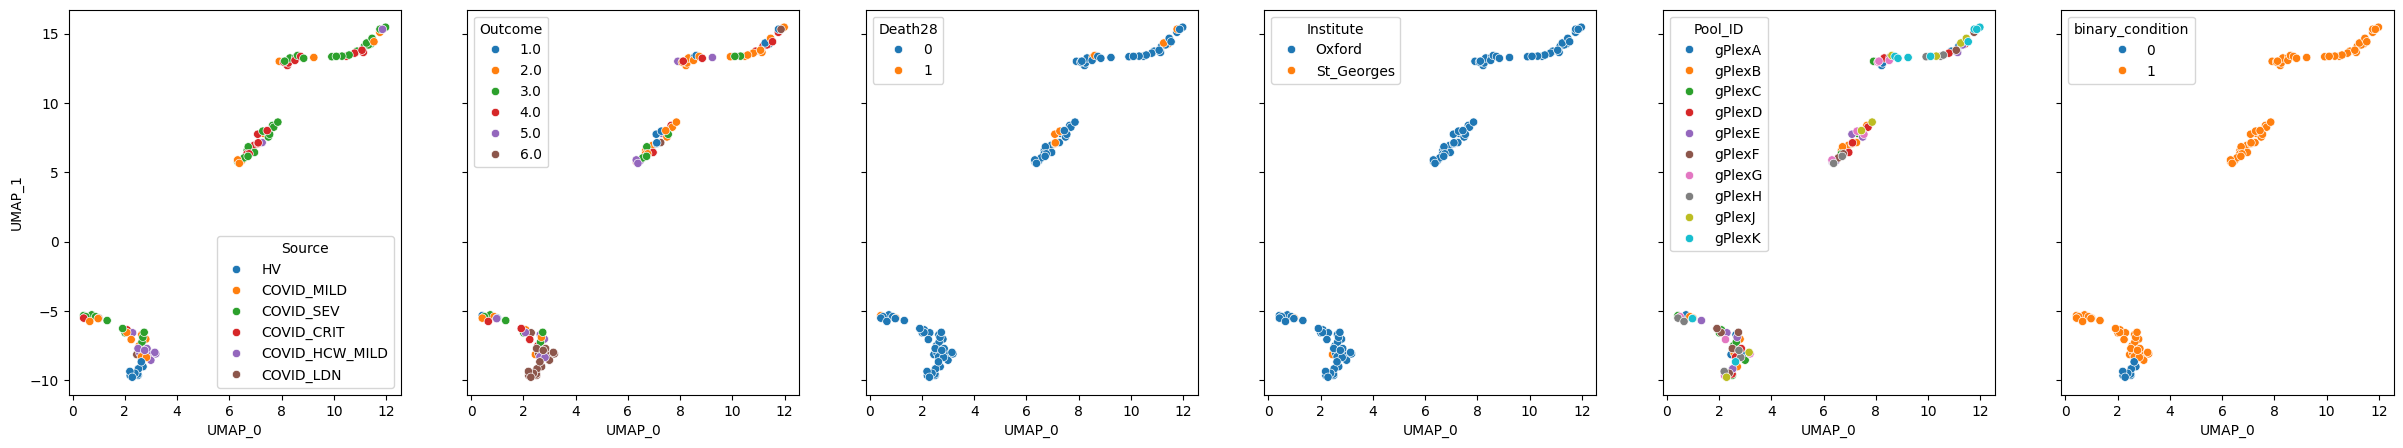

In [ ]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

While it is not clear why we see 3 clusters, healthy volunteers are clearly grouped together

Since `binary_condition` was specified as a label during training, we can predict this label with PaSCient's classifier:

In [ ]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.000044,0.999956,1
S00112-Ja003E-PBCa,0.003916,0.996083,1
S00005-Ja005E-PBCa,0.000296,0.999704,1
S00061-Ja003E-PBCa,0.000095,0.999905,1
S00056-Ja003E-PBCa,0.002233,0.997767,1
...,...,...,...
S00076-Ja001E-PBCa,0.002672,0.997328,1
S00072-Ja001E-PBCa,0.000039,0.999961,1
S00065-Ja003E-PBCa,0.000191,0.999809,1
S00048-Ja003E-PBCa,0.000182,0.999818,1


In [ ]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        91

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



Now let's challenge paSCient with a more complex task of multilabel classification of disease severities:

In [ ]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [ ]:
pascient.fine_tune("Source", tasks="classification")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.394535,0.025477,0.025743,0.144956,0.409188,0.000101,COVID_SEV
S00112-Ja003E-PBCa,0.063328,0.267164,0.217097,0.295604,0.150487,0.006321,COVID_MILD
S00005-Ja005E-PBCa,0.880595,0.003001,0.008579,0.024722,0.083051,0.000052,COVID_CRIT
S00061-Ja003E-PBCa,0.388946,0.029524,0.029042,0.148687,0.403622,0.000178,COVID_SEV
S00056-Ja003E-PBCa,0.210393,0.132618,0.112567,0.244251,0.297248,0.002924,COVID_SEV
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.125680,0.192639,0.150116,0.281483,0.246566,0.003515,COVID_MILD
S00072-Ja001E-PBCa,0.361417,0.029526,0.027950,0.170613,0.410370,0.000123,COVID_SEV
S00065-Ja003E-PBCa,0.398539,0.032703,0.032377,0.143577,0.392591,0.000213,COVID_CRIT
S00048-Ja003E-PBCa,0.378879,0.033592,0.032130,0.151074,0.404112,0.000212,COVID_SEV


In [ ]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.68      0.72      0.70        18
COVID_HCW_MILD       0.59      0.83      0.69        12
     COVID_LDN       0.00      0.00      0.00         2
    COVID_MILD       0.60      0.50      0.55        18
     COVID_SEV       0.72      0.71      0.72        41
            HV       1.00      1.00      1.00        10

      accuracy                           0.70       101
     macro avg       0.60      0.63      0.61       101
  weighted avg       0.69      0.70      0.69       101



/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

Not bad! PaSCient achieves macro F1 score of 0.61, the best we've seen so far

The sample embeddings has changed after fine-tuning as the entire model was retrained. Let's visualise them:

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


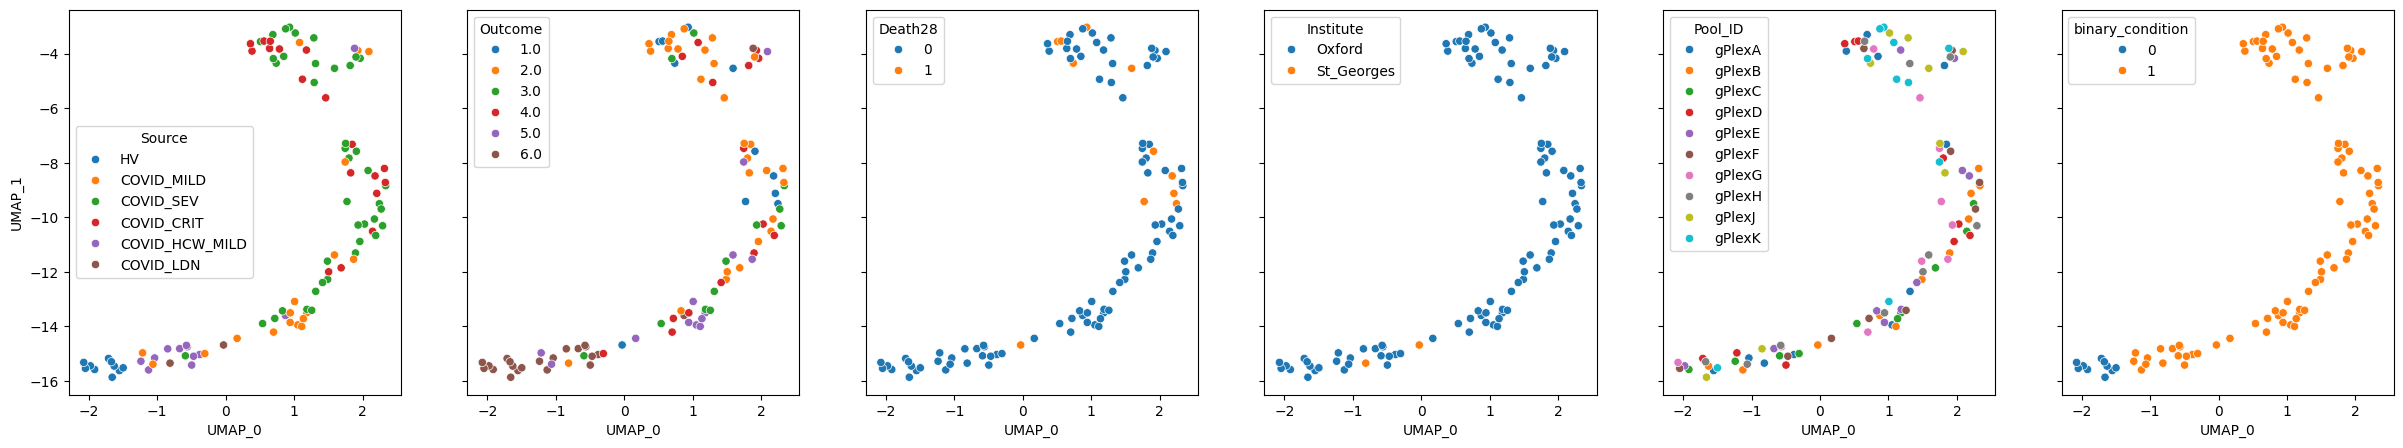

In [ ]:
pascient_distances = pascient.calculate_distance_matrix()
pascient.embed("UMAP")
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

### Cell importance

PaSCient can compute per-cell importance scores to identify which cells contribute most to sample-level representations.

> **Note:** By default, `get_cell_importance()` uses Integrated Gradients (IG) from the PaSCient paper when [captum](https://captum.ai/) is installed, and falls back to cosine similarity between cell and sample embeddings otherwise.

In [ ]:
cell_importance = pascient.get_cell_importance(target=1)
importance_scores = cell_importance.iloc[:, 0]
print(f"Importance scores: min={importance_scores.min():.4f}, max={importance_scores.max():.4f}, mean={importance_scores.mean():.4f}")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


Importance scores: min=0.0000, max=0.0415, mean=0.0000


### Cell importance by disease severity and cell type

Visualize the distribution of cell importance scores. Since most scores are near zero with a long tail of important cells, we use strip plots with log-scaled y-axis for better visibility.

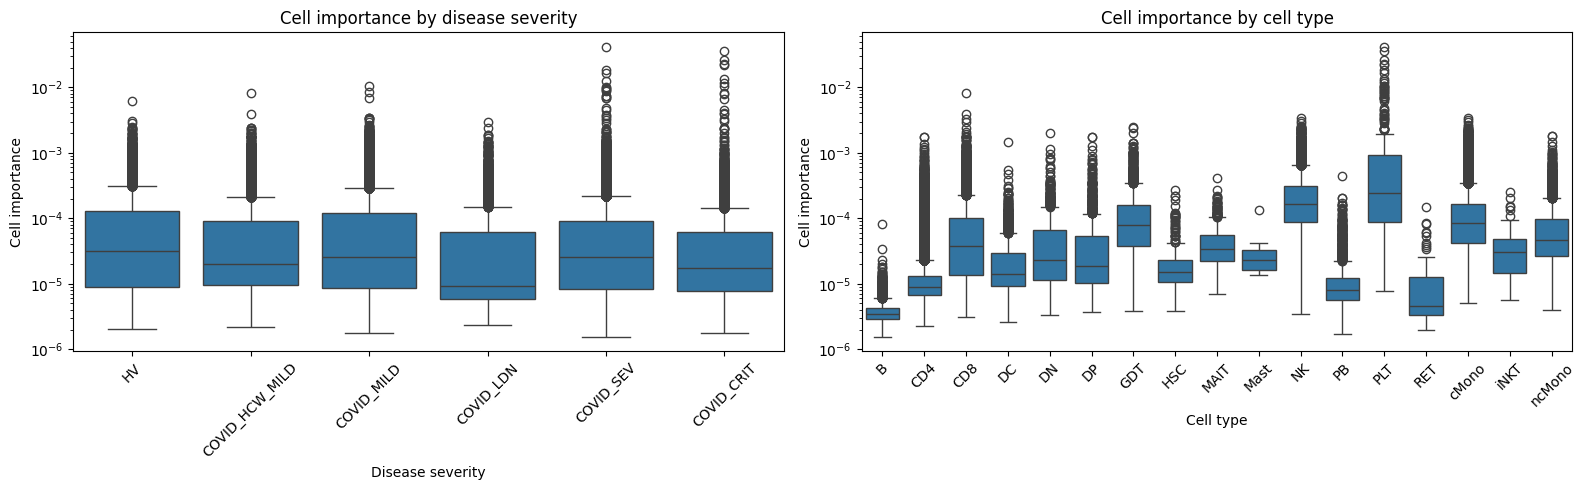

In [ ]:
import seaborn as sns

# Build dataframe with importance scores and metadata
cell_imp_df = pd.DataFrame({
    "importance": importance_scores,
    "Source": adata.obs["Source"].values,
    "cell_type": adata.obs[cell_type_key].values,
}, index=adata.obs_names)

severity_order = ["HV", "COVID_HCW_MILD", "COVID_MILD", "COVID_LDN", "COVID_SEV", "COVID_CRIT"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter to nonzero for log-scale
nonzero = cell_imp_df[cell_imp_df["importance"] > 0]

# By disease severity
ax = axes[0]
sns.boxplot(data=nonzero, x="Source", y="importance", order=severity_order, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Disease severity")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by disease severity")
ax.tick_params(axis="x", rotation=45)

# By cell type
ax = axes[1]
sns.boxplot(data=nonzero, x="cell_type", y="importance", ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Cell type")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by cell type")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The distributions per disease severity look quite similar, but maximum cell importances seem larger for more severe COVID stages

### Summary statistics

Descriptive statistics of cell importance scores grouped by disease severity and cell type.

In [ ]:
print("=== Cell importance by disease severity ===")
cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)

=== Cell importance by disease severity ===


/localscratch/vladimir.shitov/ipykernel_540455/745167923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
HV,87204.0,0.000018,0.000088,0.0,0.0,0.0,0.000000,0.006155
COVID_HCW_MILD,84359.0,0.000018,0.000088,0.0,0.0,0.0,0.000000,0.008232
COVID_MILD,107376.0,0.000027,0.000121,0.0,0.0,0.0,0.000003,0.010584
COVID_LDN,14832.0,0.000017,0.000093,0.0,0.0,0.0,0.000000,0.002996
COVID_SEV,230343.0,0.000021,0.000139,0.0,0.0,0.0,0.000004,0.041486
COVID_CRIT,87620.0,0.000018,0.000210,0.0,0.0,0.0,0.000007,0.035924


In [ ]:
print("=== Cell importance by cell type (sorted by max) ===")
cell_imp_df.groupby("cell_type")["importance"].describe().round(6).sort_values("max", ascending=False)

=== Cell importance by cell type (sorted by max) ===


/localscratch/vladimir.shitov/ipykernel_540455/3781085762.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("cell_type")["importance"].describe().round(6).sort_values("max", ascending=False)


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
PLT,920.0,0.000544,0.002747,0.0,0.0,0.0,0.000052,0.041486
CD8,87562.0,0.000020,0.000078,0.0,0.0,0.0,0.000000,0.008232
cMono,152220.0,0.000035,0.000105,0.0,0.0,0.0,0.000015,0.003444
NK,57648.0,0.000058,0.000161,0.0,0.0,0.0,0.000000,0.003357
GDT,7935.0,0.000033,0.000109,0.0,0.0,0.0,0.000000,0.002455
DN,3426.0,0.000015,0.000066,0.0,0.0,0.0,0.000000,0.002018
ncMono,21281.0,0.000019,0.000062,0.0,0.0,0.0,0.000000,0.001800
DP,5354.0,0.000014,0.000064,0.0,0.0,0.0,0.000000,0.001764
CD4,218353.0,0.000004,0.000017,0.0,0.0,0.0,0.000000,0.001737


In this tutorial you learned how to run supervised sample-level methods, evaluate and visualise the results with `patpy`